Notebook Implementation of the paper "Attention Is All You Need" by Vaswani et al., 2017. https://arxiv.org/abs/1706.03762*

Reference: https://colab.research.google.com/github/jaygala24/pytorch-implementations/blob/master/Attention%20Is%20All%20You%20Need.ipynb#scrollTo=AxYEXnogyq3T

In [2]:
import math 
import torch
import torch.nn as nn
from torch.nn import functional as nf

#### <u>Scaled Dot Product Attention</u>

$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{Q K^T}{\sqrt{d_k}}) V
$$

> *What is learned ?*


In [3]:
class ScaledDotProductAttention(nn.Module):
    """Computes scaled dot product attention"""

    def __init__(self, scale, dropout_rate):
        super().__init__()
        self.scale = scale
        self.dropout_rate = dropout_rate

        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: torch.Tensor = None,
    ):
        """
        query: (batch_size, n_heads, query_len, head_dim)
        key: (batch_size, n_heads, key_len, head_dim)
        value: (batch_size, n_heads, value_len, head_dim)
        mask: (batch_size, 1, 1, source_seq_len) for source mask
              (batch_size, 1, target_seq_len, target_seq_len) for target mask
        """

        # calculate alignment scores
        scores = torch.matmul(query, key.transpose(1, 2))
        scores = scores / self.scale

        # mask out invalid positions
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        # calculate the attentiion weights (prob) from alignment scores
        attn_probs = nf.softmax(scores, dim=-1)

        # calculate context vector
        output = torch.matmul(
            self.dropout(attn_probs), value
        )  # (batch_size, n_heads, query_len, head_dim)

        return output, attn_probs


#### <u>Multi-head attention</u>

Let $W_i^Q$, $W_i^K$, $W_i^V$ and $W_i^O$ real matrices such as:

$
W_i^Q \in \mathbb{R}^{\mathrm{d_{model}\times d_k}} \\ W_i^K \in \mathbb{R}^{\mathrm{d_{model}\times d_k}} \\ W_i^V \in \mathbb{R}^{\mathrm{d_{model}\times d_v}} \\ W_i^O \in \mathbb{R}^{\mathrm{hd_v\times d_{model}}} \\\\
$

The Multi-head attention layer is defined as:
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O \\
$$
$$
\text{where}\ \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V) \\
$$

1. the inputs: query matrix $Q$, key matrix $K$ and value matrix $V$ are linearly projected using $W^Q$, $W^K$ and $W^V$. 
2. The projected query $QW^Q$, key $KW^K$ and value $VW^V$ are split into $h$ heads. 
3. Scaled dot-product attention is computed for each head $i$. 
4. The independent attention head computed are then concatenated and linearly projected using $W^O$.

> *The learned weights are $W_i^Q$, $W_i^K$, $W_i^V$ and $W_i^O$*


In [7]:
class MultiHeadAttention(nn.Module):
    """
    Implements Multi-head Self-Attention
    """

    def __init__(self, model_dim, n_heads, dropout_rate=0.1):
        super().__init__()

        if not model_dim % n_heads == 0:
            raise ValueError("`model_dim` must be a multiple of `n_heads`")

        self.model_dim = model_dim
        self.n_heads = n_heads
        self.d_k = self.d_v = model_dim // n_heads

        self.dropout_rate = dropout_rate

        self.W_q = nn.Linear(model_dim, model_dim, bias=False)
        self.W_k = nn.Linear(model_dim, model_dim, bias=False)
        self.W_v = nn.Linear(model_dim, model_dim, bias=False)
        self.W_o = nn.Linear(model_dim, model_dim)

        self.attention = ScaledDotProductAttention(
            scale=math.sqrt(self.d_k),
            dropout_rate=self.dropout_rate,
        )

    def split_heads(self, x):
        """
        x: (batch_size, seq_len, model_dim)
        """

        batch_size = x.size(0)

        # Tensor.view(*shape) returns a new tensor with the same data as the self tensor but of a different shape.
        x = x.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # (batch_size, n_heads, seq_len, d_k)
        return x

    def group_heads(self, x):
        """
        x: (batch_size, n_heads, seq_len, head_dim)
        """
        batch_size = x.size(0)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.n_heads * self.d_k)

        # x: (batch_size, seq_len, d_model)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query: (batch_size, query_len, d_model)
        key: (batch_size, key_len, d_model)
        value: (batch_size, value_len, d_model)
        mask: (batch_size, 1, source_seq_len) for source mask
              (batch_size, target_seq_len, target_seq_len) for target mask
        """
        # 1 and 2 - apply linear projections to query, key, and value

        Q = self.split_heads(self.W_q(query))
        #   (batch_size, n_heads, query_len, head_dim)
        
        K = self.split_heads(self.W_k(key))
        #   (batch_size, n_heads, key_len, head_dim)
        
        V = self.split_heads(self.W_v(value))
        #   (batch_size, n_heads, value_len, head_dim)

        if mask is not None:
            # apply same mask for all the heads
            mask = mask.unsqueeze(1)

        # 3 - compute attention weights and context vector for each head.
        x, attn = self.attention(Q, K, V)

        # x: (batch_size, n_heads, query_len, head_dim)
        # attn: (batch_size, n_heads, query_len, value_len)

        # 4 - concatenate context vector of all heads and apply linear projection
        x = self.group_heads(x)  # (batch_size, query_len, model_dim)
        x = self.W_o(x)  # (batch_size, query_len, model_dim)

        return x, attn


#### <u>Position-wise Feed-Forward Network Module</u>

The Position-wise Feed-Forward Network is a two-layer MLP applied independently and identically to each position (token) in the sequence.

$$
FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
$$

The feed-forward sub-layer can be thought of as a non-linear “processing step” for each token after the attention sub-layer has gathered context from other tokens. It gives the model a chance to learn complex, non-linear transformations of each token’s context-enriched embedding.

> Attention isn't all you need ! :D

In [ ]:
class PositionwiseFeedForward(nn.Module):
    """
    Implement a two layer fully connected feed-forward network (MLP)
    """

    def __init__(self, model_dim, ff_dim, dropout_rate=0.1):
        super().__init__()

        self.model_dim = model_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate

        self.w_1 = nn.Linear(model_dim, ff_dim)
        self.w_2 = nn.Linear(ff_dim, model_dim)

        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(self, x):
        """
        x: (batch_size, seq_len, model_dim)
        """

        x = self.dropout(nf.relu(self.w_1(x)))  # (batch_size, seq_len, ff_dim)
        x = self.w_2(x)

        # (batch_size, seq_len, model_dim)
        return x

#### Positional Encoding Module

The attention mechanism treats all tokens in a sequence simultaneously and learns token-to-token relationships without any dependency on relative nor absolute token positions. In short, the attention mechanism is permutation-invariant and will produce the same result for a given set of tokens regardless of their order. 

The positional encoding module's purpose is to encode information about absolute position into the tokens' represention so that the model can leverage relative or absolute position to compute token-to-tokens relationships.

In the original Transformer (Vaswani et al., 2017), Sinusoidal positional encodings are used with different frequencies to unique represent the order and the position of the token in sequence. The position of a token is encoded through sinusoidal function with different frequencies for each dimension resulting in a unique vector for each position. 

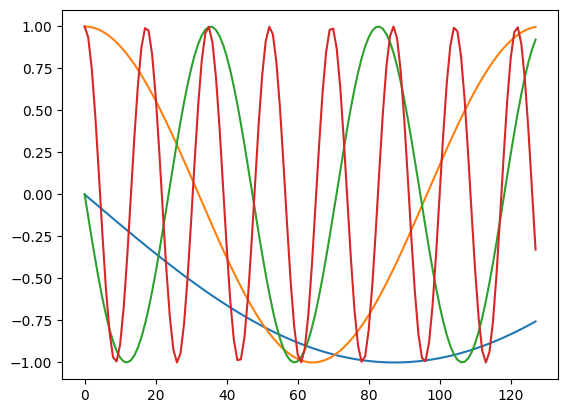

In [18]:
import matplotlib.pyplot as plt
import numpy as np

dim = 512
pos_len = np.arange(0, dim)
d1 = math.exp(0) * (-math.log(10000) / dim)
d2 = math.exp(1) * (-math.log(10000) / dim)
d3 = math.exp(2) * (-math.log(10000) / dim)
d4 = math.exp(3) * (-math.log(10000) / dim)

n_pos = 128
plt.plot(pos_len[:n_pos], np.sin(d1 * pos_len)[:n_pos])
plt.plot(pos_len[:n_pos], np.cos(d2 * pos_len)[:n_pos])
plt.plot(pos_len[:n_pos], np.sin(d3 * pos_len)[:n_pos])
plt.plot(pos_len[:n_pos], np.cos(d4 * pos_len)[:n_pos])

# illustrate how each position (x axis) has a unique set (vector) of values across the dimensions (y axis).
plt.show()

In [ ]:
class PositionalEncoding(nn.Module):
    """
    Implements the sinusoidal position encoding
    """

    def __init__(self, model_dim, dropout_rate=0.1, max_len=5000):
        super().__init__()

        self.model_dim = model_dim
        self.dropout_rate = dropout_rate
        self.max_len = max_len

        self.dropout = nn.Dropout(self.dropout_rate)

        # compute positional encoding
        positional_encoding_matrix = torch.zeros(self.max_len, self.model_dim)

        position = torch.arange(
            0,
            self.max_len,
            dtype=torch.float,
        ).unsqueeze(1)  # max_len, 1

        div_term = torch.exp(
            torch.arange(0, self.model_dim).float()
            * (-math.log(10000.0) / self.model_dim)
        )

        positional_encoding_matrix[:, 0::2] = torch.sin(position * div_term)
        positional_encoding_matrix[:, 1::2] = torch.cos(position * div_term)

        positional_encoding_matrix = positional_encoding_matrix.unsqueeze(0).transpose(
            0, 1
        )

        self.register_buffer(
            "positional_encoding_matrix",
            positional_encoding_matrix,
        )

    def forward(self, x):
        """
        x: (batch_size, seq_len, model_dim)
        """

        x = x + self.positional_encoding_matrix[: x.size(0), :]
        #   (batch_size, seq_len, model_dim)

        x = self.dropout(x) # (batch_size, seq_len, model_dim)

        return x


#### Encoder Module

The encoder module doesn't add any new part. It assemble the previously built modules to make them come together to form the first half of the complete transformer model. It is built by stacking multiple layers that combine the previously defined modules. 

It consists of a stack of N=6 identical layers, each containing two sub-layers, a multi-head self-attention layer, and a position-wise fully connected feed-forward network with a residual connection and layer normalization after each sub-layer.

In [ ]:
class EncoderLayer(nn.Module):
    """
    one encoder layer is made up of a self-attention layer and a feed-forward fc layer.
    """

    def __init__(self, model_dim, n_heads, ff_dim, dropout_rate=0.1):
        super().__init__()
        self.model_dim = model_dim
        self.ff_dim = ff_dim
        self.n_heads = n_heads
        self.dropout_rate = dropout_rate

        self.attention_layer = MultiHeadAttention(
            model_dim=self.model_dim,
            n_heads=self.n_heads,
            dropout_rate=self.dropout_rate,
        )
        self.attention_layer_norm = nn.LayerNorm(self.model_dim, eps=1e-6)

        self.feed_forward_layer = PositionwiseFeedForward(
            model_dim=self.model_dim,
            ff_dim=self.ff_dim,
            dropout_rate=self.dropout_rate,
        )
        self.feed_forward_layer_norm = nn.LayerNorm(self.model_dim, eps=1e-6)

        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(self, x, mask):
        """
        x: (batch_size, source_seq_len, model_dim)
        mask: (batch_size, 1, source_seq_len)
        """

        # apply self-attention
        x1, _ = self.attention_layer(x, x, x, mask)

        # apply residual connection followed by layer normalization
        x = self.attention_layer_norm(x + self.dropout(x1))

        # apply position-wise feed-forward
        x1 = self.feed_forward_layer(x)

        # apply residual connection followed by layer normalization
        x = self.feed_forward_layer_norm(x + self.dropout(x1))

        return x
